In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
weighted_returns_df = pd.read_csv("data/outputs/baseline_portfolio",
                                  index_col = 0, parse_dates = [1])
daily_df_annually = pd.read_csv("data/outputs/annually_reblanced_portfolio",
                                index_col = 0, parse_dates = [1])
daily_df_quarterly = pd.read_csv("data/outputs/quarterly_reblanced_portfolio",
                                 index_col = 0, parse_dates = [1])
daily_df_quarterly_band = pd.read_csv("data/outputs/quarterly_reblanced_byband_portfolio", 
                                      index_col = 0, parse_dates = [1])
annual_weights_frame = pd.read_csv("data/outputs/annually_rebalanced_weights",
                                index_col = 0, parse_dates=[1])
quarterly_weights_frame= pd.read_csv("data/outputs/quarterly_rebalanced_weights",
                                index_col = 0, parse_dates=[1])
band_weights_frame = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights",
                                index_col = 0, parse_dates=[1])

In [85]:
## Portfolio Drift ##


def drift_evaluation(df):
    starting_weights = df[df["weight_type"] == "starting"]
    ending_weights = df[df["weight_type"] == "ending"]

    difference = np.array(ending_weights.drop(columns=['Date','weight_type'])) - np.array(starting_weights.drop(columns=['Date','weight_type']))

    drift_list = []

    for period in range(len(difference)):
        start_date = starting_weights['Date'].iloc[period]
        end_date = ending_weights['Date'].iloc[period]

        drift = abs(difference[period]).sum()
        drift_list.append({
            "Start": start_date,
            "End" : end_date,
            "Drift": drift
            })

    return pd.DataFrame(drift_list)


In [86]:
annual_drift = drift_evaluation(annual_weights_frame)
quarterly_drift = drift_evaluation(quarterly_weights_frame)
band_drift = drift_evaluation(band_weights_frame)


In [87]:
## Trades ##
def calculate_trades(df):
    starting_weights = df[df["weight_type"] == "starting"]
    ending_weights = df[df["weight_type"] == "ending"]
    starting_weights_next = starting_weights.drop(starting_weights.index[0])
    ending_weights_current = ending_weights.drop(ending_weights.index[-1])
    start = starting_weights_next.drop(columns=['Date','weight_type'])
    end = ending_weights_current.drop(columns=['Date','weight_type'])
    trades = np.array(start) - np.array(end)
    trades_df = pd.DataFrame(trades, index = starting_weights_next['Date'], columns = start.columns)
    return trades_df


In [88]:
annual_trades_df = calculate_trades(annual_weights_frame)
quarterly_trades = calculate_trades(quarterly_weights_frame)
band_trades = calculate_trades(band_weights_frame)

In [89]:
## Turnover ## 
def calculate_turnover(df):
    turnover_list = []
    for row in range(len(df.index)):
        turnover = abs(df.iloc[row]).sum(axis = 0) * 0.5
        turnover_list.append({
            'Date':df.index[row],
            'turnover': turnover
            })
    return pd.DataFrame(turnover_list)


In [90]:
annual_portfolio_turnover = calculate_turnover(annual_trades_df)
quarterly_portfolio_turnover = calculate_turnover(quarterly_trades)
band_portfolio_turnover = calculate_turnover(band_trades)

In [91]:
def simulate_transaction_costs(df, turnover_df, bp):

    tc = bp/10000

    df = df.copy()
    gross_value = df['portfolio_value']
    df2 = df.drop(columns = 'portfolio_value')

    turnover_series = turnover_df.set_index('Date').squeeze()

    df2['turnover'] = df2['Date'].map(turnover_series)

    previous_value = 1.0
    cummulative_cost = 0

    for index, row in df2.iterrows():

        past_value = previous_value
        growth = 1 + row["portfolio_return"]
        value = past_value * growth

        turnover = row["turnover"]

        if row["Rebalanced"] == 1 and pd.notna(turnover):
            cost = value * tc * turnover
        else:
            cost = 0

        cummulative_cost += cost

        portfolio_value = value - cost

        df2.loc[index, "past_value"] = past_value
        df2.loc[index, "growth"] = growth
        df2.loc[index, "value"] = value
        df2.loc[index, "cost"] = cost
        df2.loc[index, "portfolio_value"] = portfolio_value
        df2.loc[index, "cummulative_cost"] = cummulative_cost

        previous_value = portfolio_value

    df2['gross_value'] = gross_value
    return df2


In [92]:
bp = 75

annual_value_adjusted = simulate_transaction_costs(
    df = daily_df_annually,
    turnover_df=annual_portfolio_turnover,
    bp = bp
)
quarterly_value_adjusted = simulate_transaction_costs(
    df = daily_df_quarterly,
    turnover_df=quarterly_portfolio_turnover,
    bp = bp
)
band_value_adjusted = simulate_transaction_costs(
    df = daily_df_quarterly_band,
    turnover_df=band_portfolio_turnover,
    bp = bp
)

Text(2026-09-08 00:00:00, 1.46, '1.45')

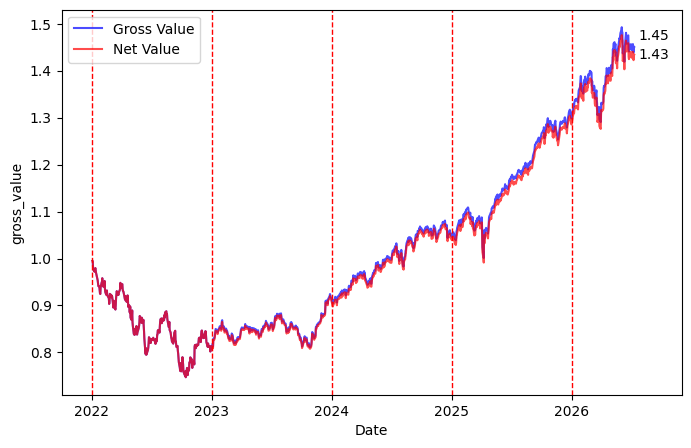

In [93]:
rebalance_days = annual_value_adjusted.loc[annual_value_adjusted['Rebalanced'] == 1, 'Date']
plt.figure(figsize= (8,5))

sns.lineplot(data = annual_value_adjusted, x = 'Date', y = 'gross_value', color='blue', label = "Gross Value", alpha = 0.7)
sns.lineplot(data = annual_value_adjusted, x = 'Date', y = 'portfolio_value', color = 'red', label = "Net Value", alpha = 0.7)

plt.legend()
for day in rebalance_days:
    plt.axvline(x=day, color="red", linestyle="--", linewidth=1)

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

x1 = annual_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y1 = annual_value_adjusted['portfolio_value'].iloc[-1].round(2) 
y1_pos = y1 - 0.01

plt.text(
        x=x1,
        y=y1_pos,  
        s=f"{y1}", 
        ha="center",  
        va="bottom",  
        fontsize=10,
        color="black",
    )

x2 = annual_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y2 = annual_value_adjusted['gross_value'].iloc[-1].round(2) 
y2_pos = y2+ 0.01

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x2,
        y=y2_pos,  
        s=f"{y2}", 
        ha="center", 
        va="bottom", 
        fontsize=10,
        color="black",
    )

In [94]:
quarterly_value_adjusted['portfolio_value'].tail(1)

1132    1.478226
Name: portfolio_value, dtype: float64

Text(2026-09-08 00:00:00, 1.528, '1.518')

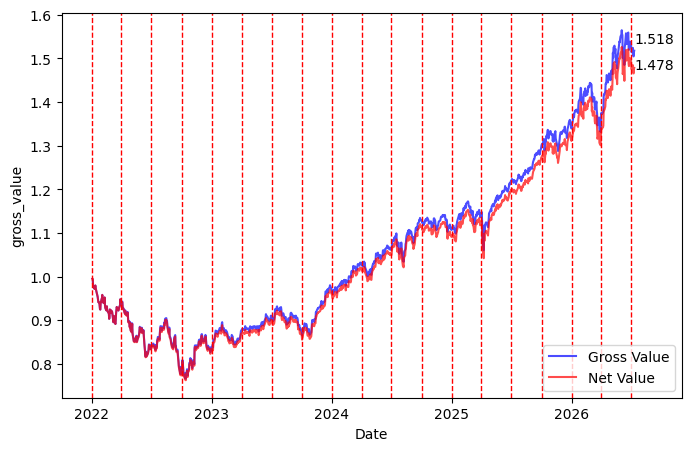

In [95]:
rebalance_days = quarterly_value_adjusted.loc[quarterly_value_adjusted['Rebalanced'] == 1, 'Date']
plt.figure(figsize= (8,5))

sns.lineplot(data = quarterly_value_adjusted, x = 'Date', y = 'gross_value', color='blue', label = "Gross Value", alpha = 0.7)
sns.lineplot(data = quarterly_value_adjusted, x = 'Date', y = 'portfolio_value', color = 'red', label = "Net Value", alpha = 0.7)

plt.legend()
for day in rebalance_days:
    plt.axvline(x=day, color="red", linestyle="--", linewidth=1)

x1 = quarterly_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y1 = quarterly_value_adjusted['portfolio_value'].iloc[-1].round(3)
y1_pos = y1 - 0.01

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x1,
        y=y1_pos, 
        s=f"{y1}",  
        ha="center", 
        va="bottom",  
        fontsize=10,
        color="black",
    )

x2 = quarterly_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y2 = quarterly_value_adjusted['gross_value'].iloc[-1].round(3)
y2_pos = y2 + 0.01

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x2,
        y=y2_pos, 
        s=f"{y2}",  
        ha="center",  
        va="bottom", 
        fontsize=10,
        color="black",
    )

Text(2026-09-08 00:00:00, 1.525, '1.505')

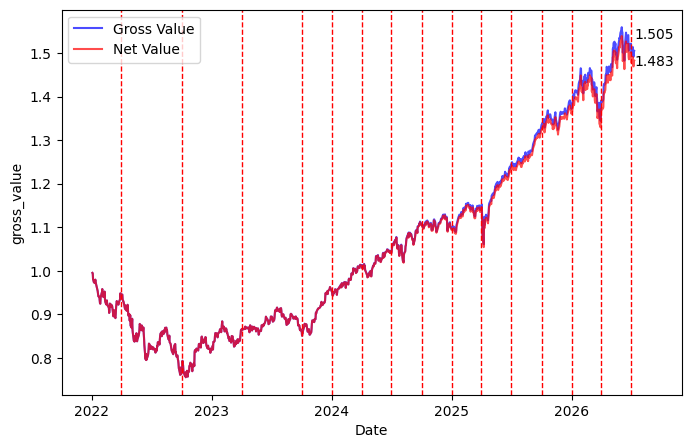

In [96]:
rebalance_days = band_value_adjusted.loc[band_value_adjusted['Rebalanced'] == 1, 'Date']
plt.figure(figsize= (8,5))

sns.lineplot(data = band_value_adjusted, x = 'Date', y = 'gross_value', color='blue', label = "Gross Value", alpha = 0.7)
sns.lineplot(data = band_value_adjusted, x = 'Date', y = 'portfolio_value', color = 'red', label = "Net Value", alpha = 0.7)

plt.legend()
for day in rebalance_days:
    plt.axvline(x=day, color="red", linestyle="--", linewidth=1)

x1 = band_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y1 = band_value_adjusted['portfolio_value'].iloc[-1].round(3)
y1_pos = y1 - 0.02

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x1,
        y=y1_pos,  
        s=f"{y1:.3f}",  
        ha="center",  
        va="bottom",  
        fontsize=10,
        color="black",
    )

x2 = band_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y2 = band_value_adjusted['gross_value'].iloc[-1].round(3)
y2_pos = y2 + 0.02

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x2,
        y=y2_pos,
        s=f"{y2:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

In [97]:
bp_list = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

def bp_loop():
    quarterly_value_dict = []
    band_value_dict = []
    for bp in bp_list:
        
        quarter = simulate_transaction_costs(
        df = daily_df_quarterly,
        turnover_df=quarterly_portfolio_turnover,
        bp = bp
        )
        quarter_value = quarter['portfolio_value'].iloc[-1]
        quarterly_value_dict.append({
            'Method' : "No Band",
            'Basis_Points': bp,
            'Net_Value' : quarter_value
        })

        
        band = simulate_transaction_costs(
        df = daily_df_quarterly_band,
        turnover_df=band_portfolio_turnover,
        bp = bp
        )
        band_value = band['portfolio_value'].iloc[-1]
        band_value_dict.append({
            'Method' : "Band",
            'Basis_Points': bp,
            'Net_Value' : band_value
        })
    
    return pd.concat([pd.DataFrame(quarterly_value_dict), pd.DataFrame(band_value_dict)])

net_value_df = bp_loop()

<Axes: xlabel='Basis_Points', ylabel='Net_Value'>

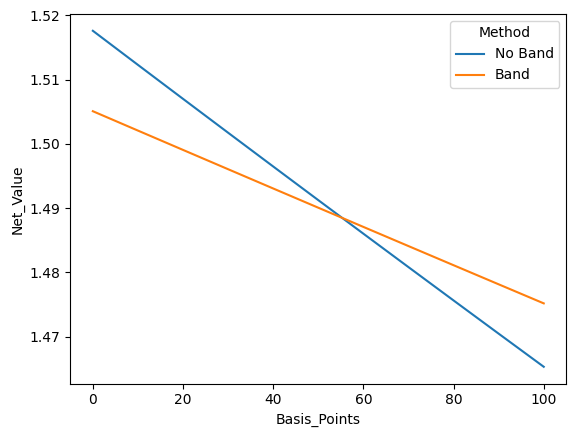

In [98]:
sns.lineplot(x = 'Basis_Points', y = 'Net_Value', hue = 'Method', data = net_value_df)


In [99]:
baseline_list = []
baseline_gross = weighted_returns_df['portfolio_value'].iloc[-1]
baseline_net = weighted_returns_df['portfolio_value'].iloc[-1]
baseline_to = 0
baseline_rebal = 0
baseline_ccost = 0
baseline_list.append({
    "strategy" : "no_rebalance",
    "net_value" : baseline_net,
    "gross_value" : baseline_gross,
    "turnover" : baseline_to,
    "reblances" : baseline_rebal,
    'cummualtive_cost': baseline_ccost
})
baseline_sum = pd.DataFrame(baseline_list)

In [100]:

def summarizer(name, df):
    summary_list = []
    
    df_net = df['portfolio_value'].iloc[-1]
    df_gross = df['gross_value'].iloc[-1]
    df_turnover = df['turnover'].mean()
    df_rebalances = df['Rebalanced'].sum()
    df_ccost = df['cummulative_cost'].iloc[-1]
    summary_list.append({
        "strategy" : name,
        "net_value" : df_net,
        "gross_value" : df_gross,
        "turnover" : df_turnover,
        "reblances" : df_rebalances,
        "cummulative_cost" : df_ccost
        })
    summary = pd.DataFrame(summary_list)

    return summary


In [101]:

annual_sum = summarizer('annually_rebalanced', annual_value_adjusted)
quarterly_sum = summarizer('quarterly_rebalanced', quarterly_value_adjusted)
banded_sum = summarizer('threshold_rebalanced', band_value_adjusted)
summary_table = pd.concat([baseline_sum, annual_sum, quarterly_sum, banded_sum])
summary_table

,strategy,net_value,gross_value,turnover,reblances,cummualtive_cost,cummulative_cost
0,no_rebalance,1.223792,1.223792,0.000000,0.0,0.0,NaN
0,annually_rebalanced,1.434236,1.450659,0.378907,5.0,NaN,0.010943
0,quarterly_rebalanced,1.478226,1.517620,0.194631,19.0,NaN,0.028196
0,threshold_rebalanced,1.482609,1.505097,0.162673,15.0,NaN,0.018959


In [102]:
annual_value_adjusted.to_csv("data/outputs/annual_ca_port")
quarterly_value_adjusted.to_csv('data/outputs/quarter_ca_port')
band_value_adjusted.to_csv("data/outputs/quarter_band_ca_port")